In [117]:
import scipy.optimize as so
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
try:
    import pySIMsalabim as sim
except ImportError: # add parent directory to sys.path if pySIMsalabim is not installed
    sys.path.append('../../../..')
    import pySIMsalabim as sim
from pySIMsalabim.aux_funcs import time_domain_DRT as drt

In [118]:
# Define plotting assistants 
# List of default colors
color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Plot parameters and sizes
plt.rc('font', size = 16)
plt.rc('axes', linewidth=1, titlesize=14)     # fontsize of the axes title
plt.rc('axes', labelsize=14)    # fontsize of the x and y labels
plt.rc('xtick', top=True, bottom=True, direction='in')
plt.rc('ytick', left=True, right=True, direction='in') 
plt.rc('figure', titlesize=5)
plt.rc('legend', fontsize=14)
plt.rc('lines', linewidth=2)

In [119]:
# Read in the simulation data
data = pd.read_csv("Simulation Results/tj.dat", sep=r'\s+')

[]

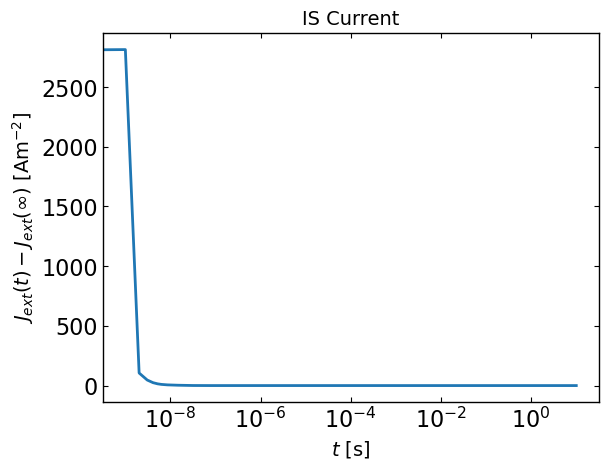

In [120]:
# Examine the exit current from the device against time
plt.plot(data['t'], data['Jext']-data['Jext'].iloc[-1])
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)-J_{ext}(\\infty)$ [$\\text{A} \\text{m}^{-2}$]')
plt.title("IS Current")
plt.plot()

In [161]:
# Define the window of time and current I will look at
start_index = 64
end_index = -1 #849
time = data['t'].iloc[start_index:end_index].values
current = data['Jext'].iloc[start_index:end_index].values
current_error = data['errJ'].iloc[start_index:end_index].values
current_upper_lim = current + current_error
current_lower_lim = current - current_error

[]

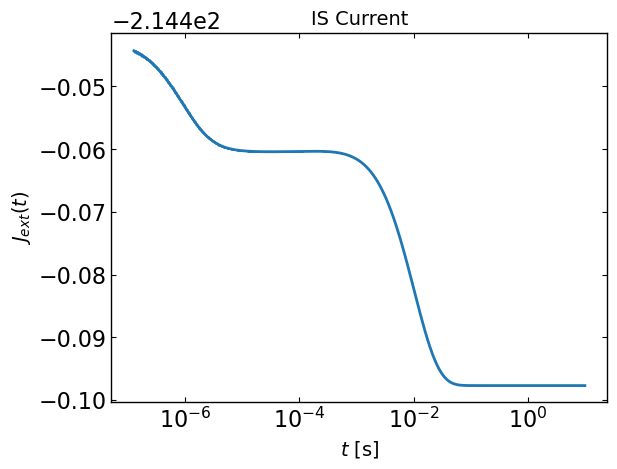

In [162]:
# Define impedance in realtime 
plt.errorbar(time, current, yerr=current_error)
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$')
plt.title("IS Current")
plt.plot()


## Finding an error threshold 

Cost function minimised by scipy.optimize.least_squares:

$$F(x) = \frac{1}{2}\sum_i (J_{\text{ext}, i}-\text{DRT}_i)^2$$

We will thus define the experimental cost threshold, the cost below which no new information is added, as:

$$F(x)_{\text{exp}} = \frac{1}{2}\sum_i \sigma_{J, i}^2$$

where $\sigma_{J, i}$ is the experimental uncertainty.

If we apply min-max scaling to $J_\text{ext}$, such that

$$J_\text{ext}' = \frac{J_\text{ext} - \text{min}(J_\text{ext})}{\text{max}(J_\text{ext}) - \text{min}(J_\text{ext})}$$

We can map errors as follows 

$$\sigma'^2 = \frac{\sigma^2}{(\text{max}(J_\text{ext}) - \text{min}(J_\text{ext}))^2}$$

In [182]:
# Calculate the cost betwen the central curve and the curves +- error to get an experimental error threshold 
cost_threshold = (1/2)*np.square(current_error).sum()
print(f"Cost Threshold: {cost_threshold:.3}")

Cost Threshold: 1.05e-06


In [164]:
# Apply scaling to the current 
scaled_current = (current - current.min())/(current.max()-current.min())
scaled_cost_threshold = cost_threshold/(current.max()-current.min())**2

In [177]:
# Find the DRT fits for m=1,...,10
# Set the values for intial guesses that don't depend on m
polarity = 1 if time[-1] < time[0] else -1
offset0 = scaled_current.max() if polarity == 1 else scaled_current.min()

# Set iteration variables
m_values = range(1,11)
fits = []

for m in m_values:
    # Set the initial guesses for parameters that do depend on m
    U0 = np.ones(m)/m
    tau0 = np.geomspace(time[0], time[-1], m)

    # Apply the fit
    fit = drt.fit_DRT_curve(time, scaled_current, U0, tau0, offset0=offset0) 

    # Add to collection of fits
    fits.append(fit)


/home/josh-edmundson/Documents/SIMsalabim-installs/pySIMsalabim/Notebooks/Projects/Den RT/IS/../../../../pySIMsalabim/aux_funcs/time_domain_DRT.py:92: RuntimeWarning: overflow encountered in exp
  calculated_DRT_curve = (U @ np.exp(-np.outer(1/tau, t))) + offset
/home/josh-edmundson/miniconda3/envs/pySIMsalabim/lib/python3.13/site-packages/scipy/optimize/_lsq/trf.py:527: RuntimeWarning: overflow encountered in dot
  cost_new = 0.5 * np.dot(f_new, f_new)
/home/josh-edmundson/Documents/SIMsalabim-installs/pySIMsalabim/Notebooks/Projects/Den RT/IS/../../../../pySIMsalabim/aux_funcs/time_domain_DRT.py:92: RuntimeWarning: invalid value encountered in matmul
  calculated_DRT_curve = (U @ np.exp(-np.outer(1/tau, t))) + offset


[]

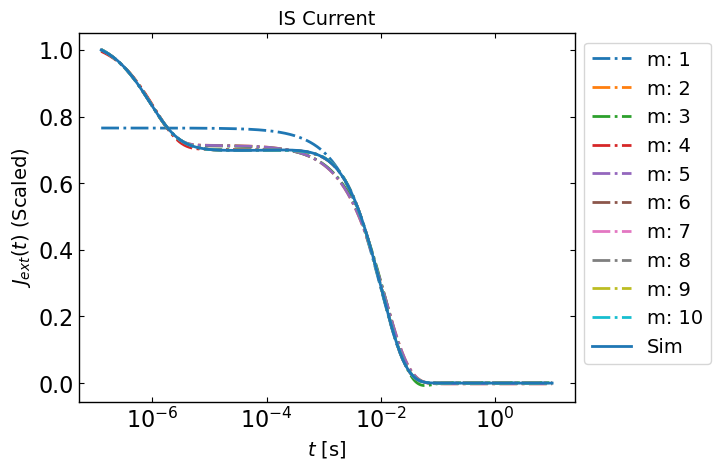

In [178]:
# Plot all the fits to make sure they make physical sense
for fit in fits: 
    plt.plot(time, fit.DRT_curve, label=f"m: {fit.m}", linestyle="-.")

plt.plot(time, scaled_current, label='Sim')
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t)$ (Scaled)')
plt.title("IS Current")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.plot()

[]

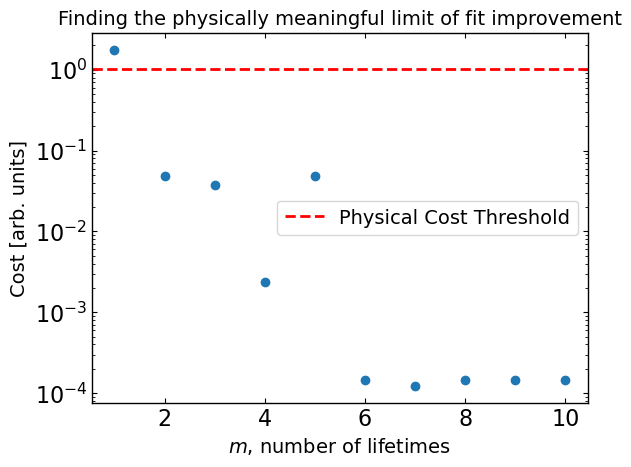

In [183]:
m_and_scaled_costs = np.array([[fit.m, fit.cost] for fit in fits])

plt.scatter(m_and_scaled_costs[:, 0], m_and_scaled_costs[:, 1])
plt.axhline(scaled_cost_threshold, linestyle='--', label='Physical Cost Threshold', color='red')
plt.xlabel('$m$, number of lifetimes')
plt.ylabel('Cost [arb. units]')
plt.yscale('log')
plt.title("Finding the physically meaningful limit of fit improvement")
plt.legend()
plt.plot()

In [180]:
fits_unscaled = drt.multi_fit_DRT_curve(time, current - data['Jext'].iloc[-1], range(1,11), U_scale_factor=1, offset0=0)

/home/josh-edmundson/miniconda3/envs/pySIMsalabim/lib/python3.13/site-packages/scipy/optimize/_lsq/common.py:234: RuntimeWarning: overflow encountered in scalar divide
  ratio = actual_reduction / predicted_reduction


[]

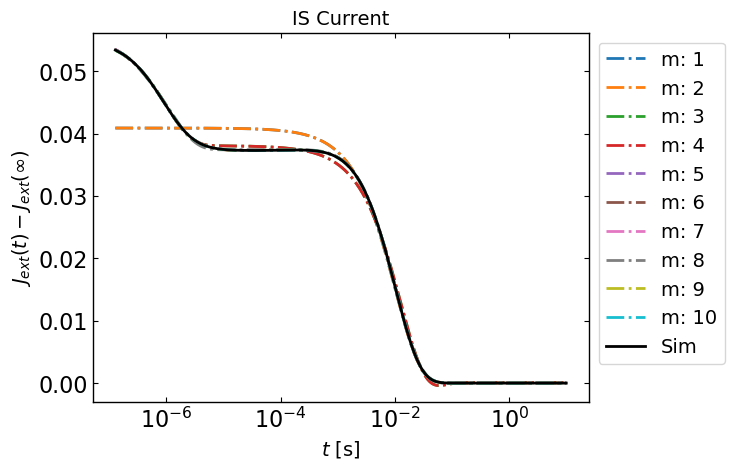

In [181]:
# Plot all the fits to make sure they make physical sense
for fit in fits_unscaled: 
    plt.plot(time, fit.DRT_curve, label=f"m: {fit.m}", linestyle="-.")

plt.plot(time, current-data['Jext'].iloc[-1], label='Sim', color='black')
plt.xscale('log')
plt.xlabel('$t$ [$\\text{s}$]')
plt.ylabel('$J_{ext}(t) - J_{ext}(\\infty)$')
plt.title("IS Current")
plt.legend(bbox_to_anchor=(1,1), loc='upper left')
plt.plot()

[]

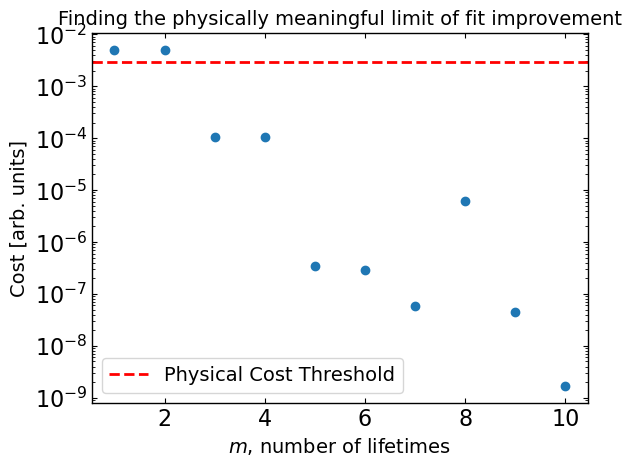

In [170]:
m_and_costs = np.array([[fit.m, fit.cost] for fit in fits_unscaled])

plt.scatter(m_and_costs[:, 0], m_and_costs[:, 1])
plt.axhline(cost_threshold, linestyle='--', label='Physical Cost Threshold', color='red')
plt.xlabel('$m$, number of lifetimes')
plt.ylabel('Cost [arb. units]')
plt.yscale('log')
plt.title("Finding the physically meaningful limit of fit improvement")
plt.legend()
plt.plot()

<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_58601/2909617755.py:18: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(time, current_error, label='$\sigma_J$', color='black', linestyle='--')


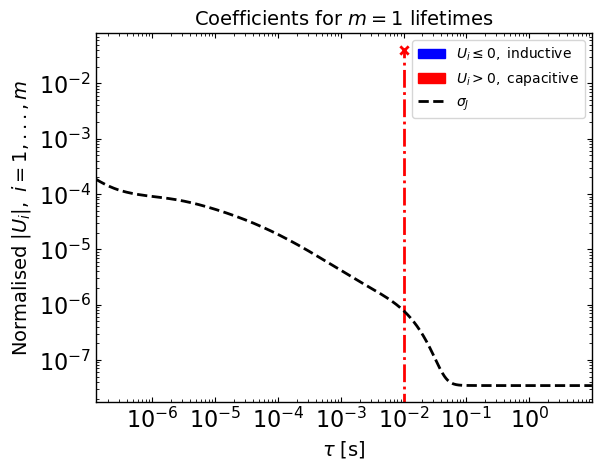

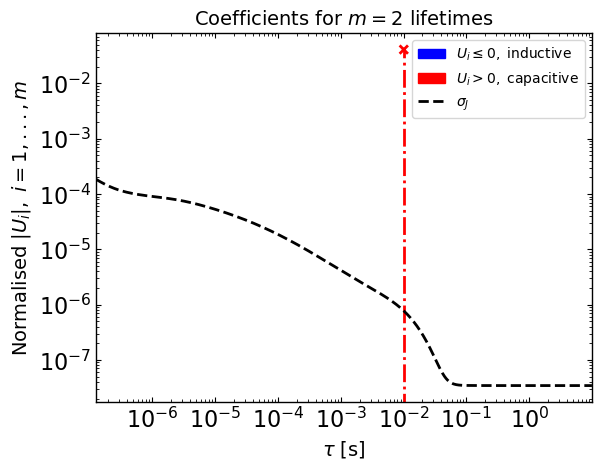

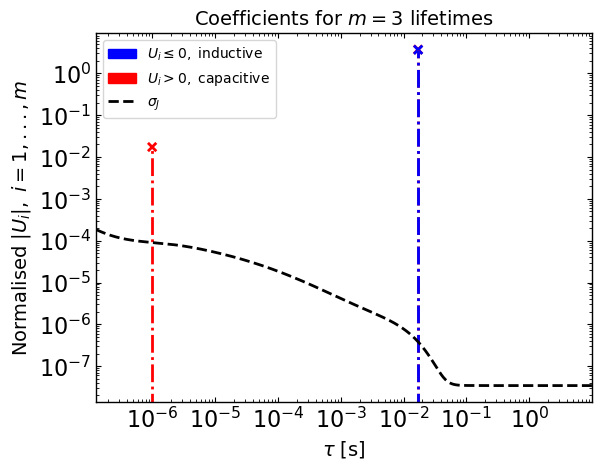

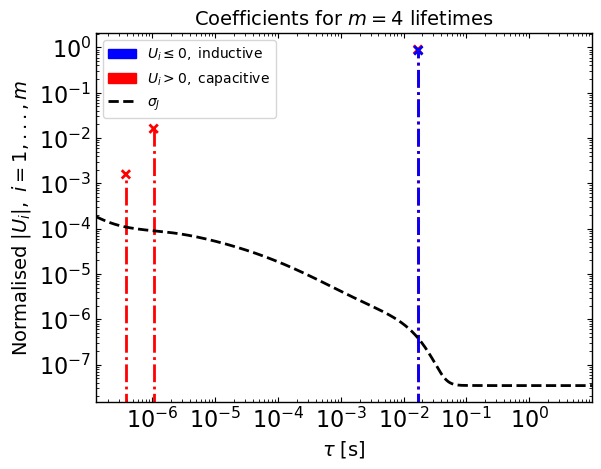

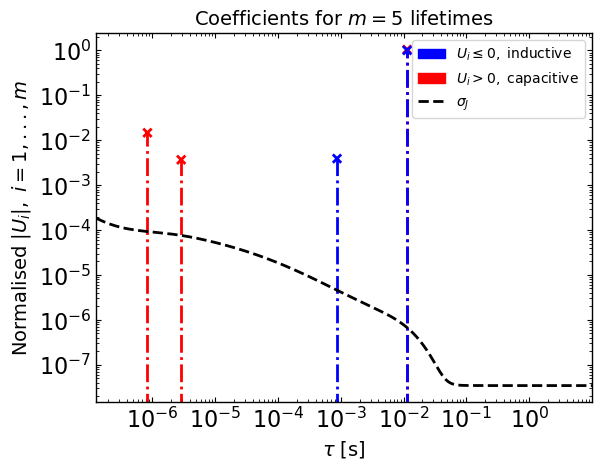

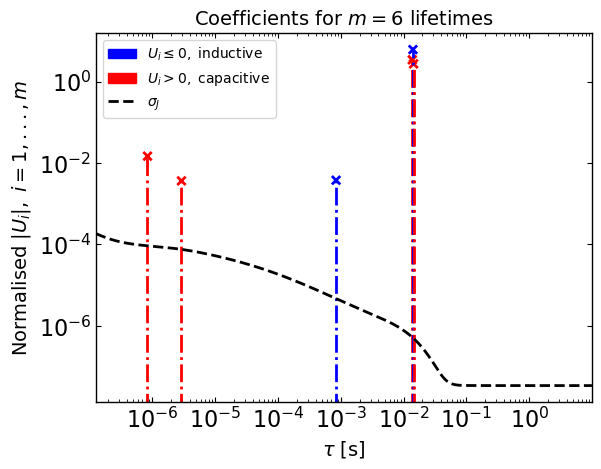

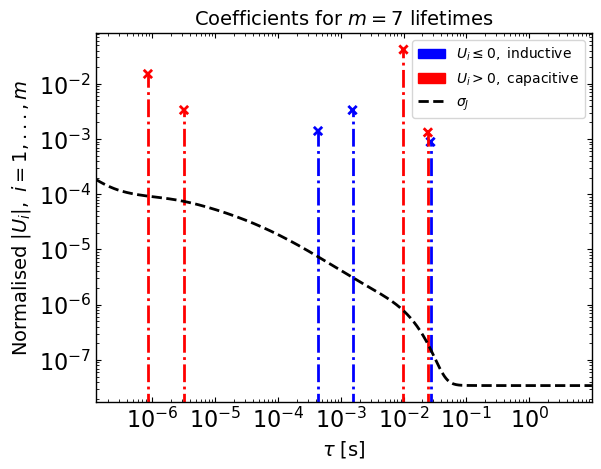

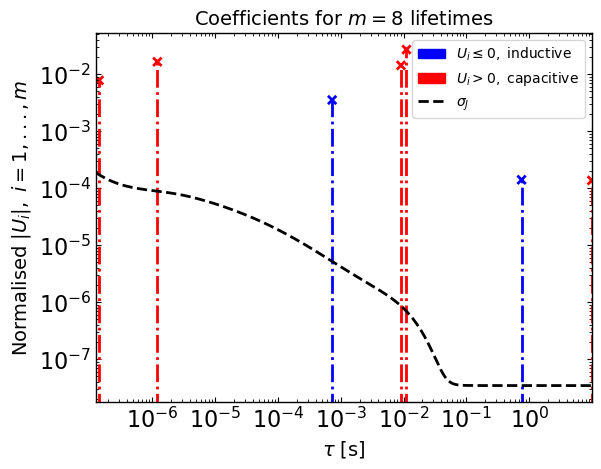

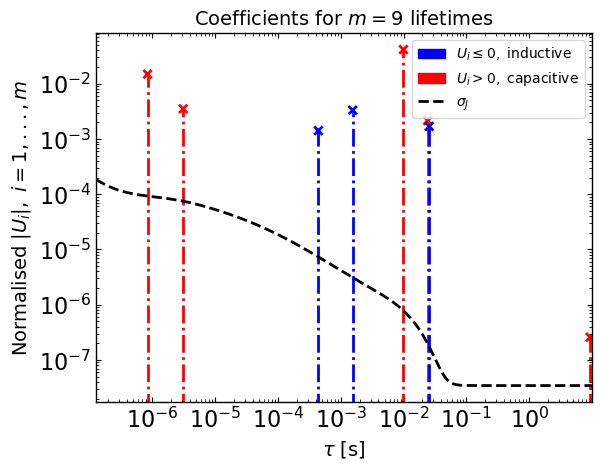

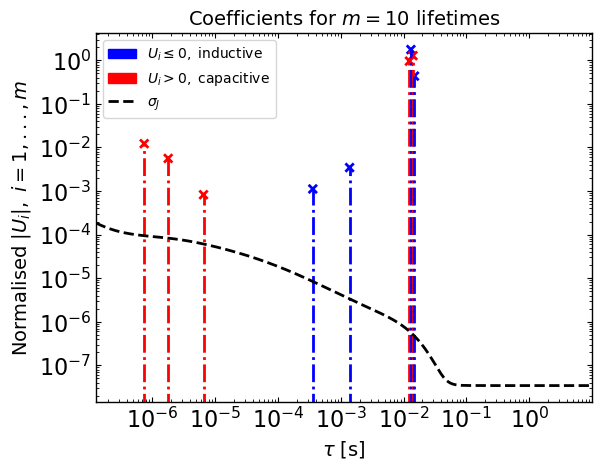

In [ ]:
import matplotlib.patches as patches
import matplotlib.lines as mlines
# Plot |U| against t for each m 
xlim = [time[0], time[-1]]
blue_patch = patches.Patch(color='blue', label='$U_i \\leq 0,$ inductive')
red_patch = patches.Patch(color='red', label='$U_i > 0, $ capacitive')
black_line = mlines.Line2D([], [], color='black', linestyle='--', label='$\\sigma_J$')

# blue_line = mlines.Line2D([], [], color='blue', linestyle='-.', marker='x', markersize=8, label='$U_i \\leq 0$')
# red_line = mlines.Line2D([], [], color='red', linestyle='-.', marker='x', markersize=8, label='$U_i > 0$')

for fit in fits_unscaled:
    polarity = fit.U > 0
    colour_map = list(map(str, np.where(polarity, 'r', 'b')))
    marker_map = list(map(str, np.where(polarity, 'x', 'v')))
    plt.vlines(fit.tau, ymin=0, ymax=np.abs(fit.U), colors=colour_map, linestyles='-.')
    plt.scatter(fit.tau, np.abs(fit.U), c=colour_map, marker='x')
    plt.plot(time, current_error_scaled, label='$\sigma_J$', color='black', linestyle='--')
    plt.xlim(xlim)
    plt.xlabel("$\\tau$ [s]")
    plt.ylabel(f"Normalised $|U_i|,$ $i = 1, ..., m$")
    plt.xscale("log")
    plt.yscale("log")
    plt.title(f"Coefficients for $m=${fit.m} lifetimes")
    plt.legend(handles =[blue_patch, red_patch, black_line], prop={'size': 10})
    plt.show()

In [172]:
print(f"m=3:    tau: {fits_unscaled[2].tau}")

# Transforming tau into frequencies 
print(f"m=3     f: {1/(2*np.pi*fits_unscaled[2].tau)}")

m=3:    tau: [1.00088688e-06 1.70315998e-02 1.71017187e-02]
m=3     f: [1.59013917e+05 9.34468545e+00 9.30637125e+00]


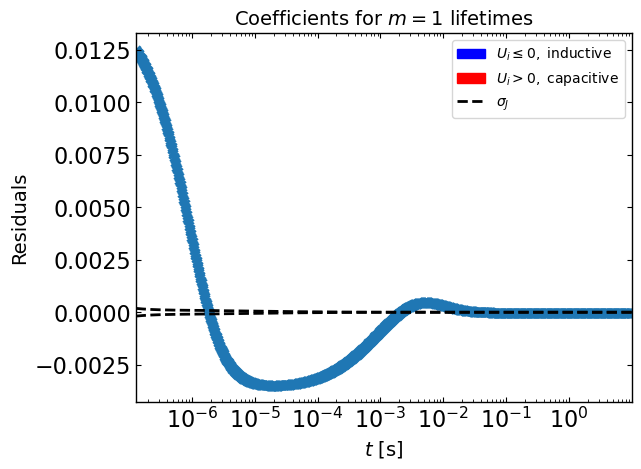

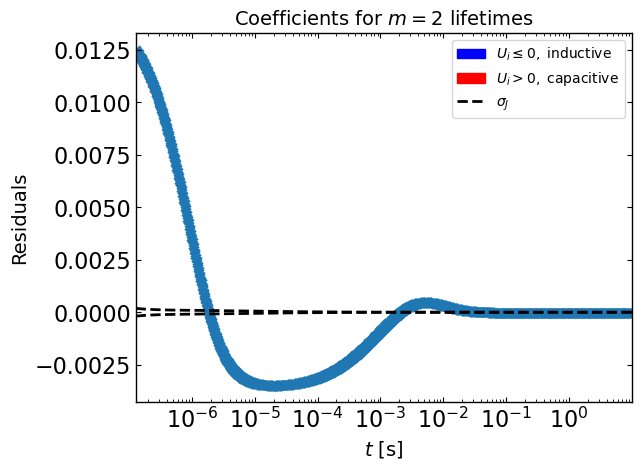

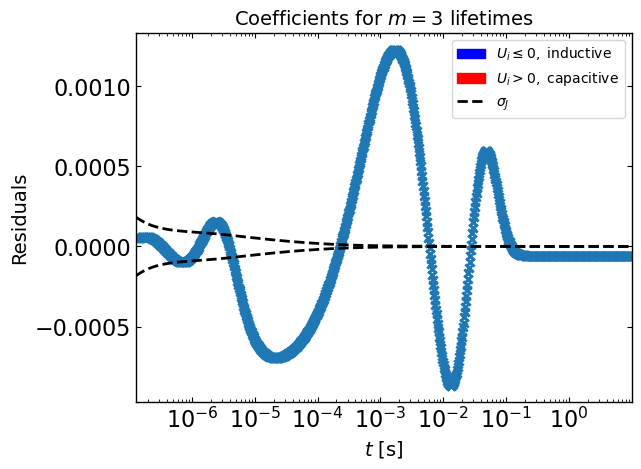

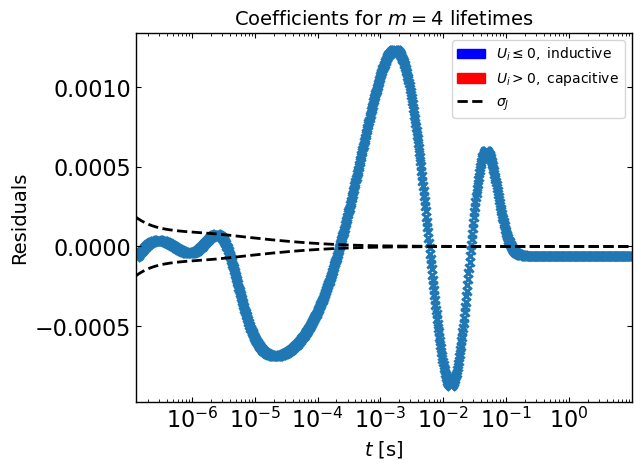

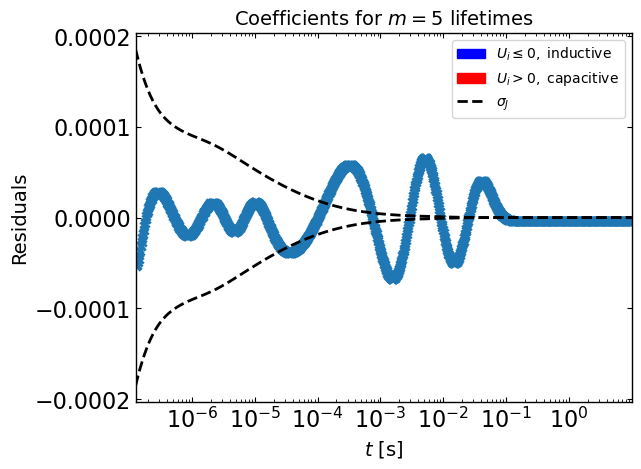

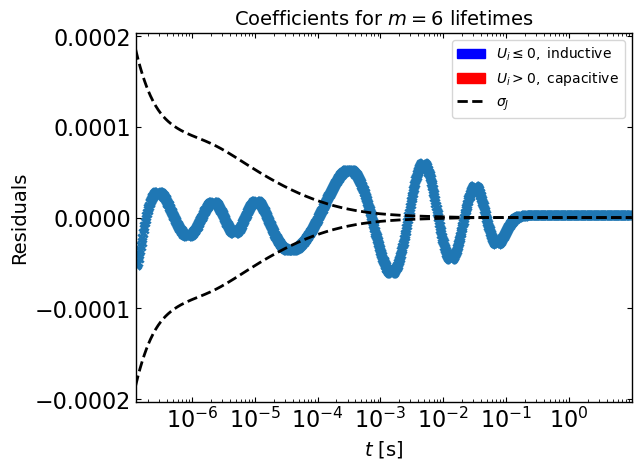

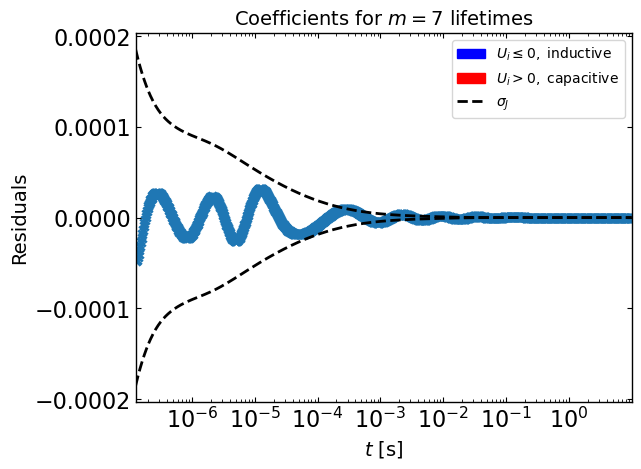

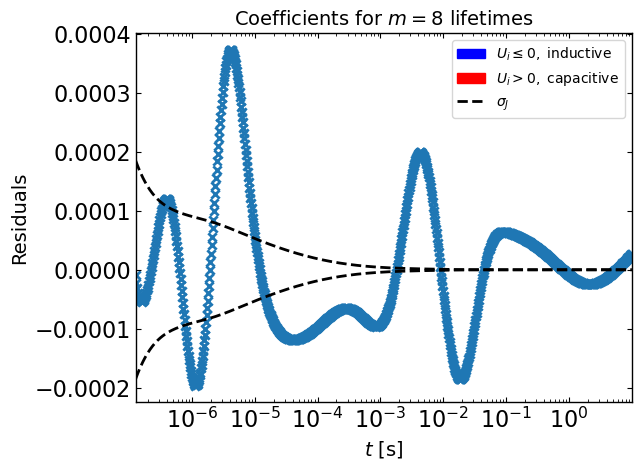

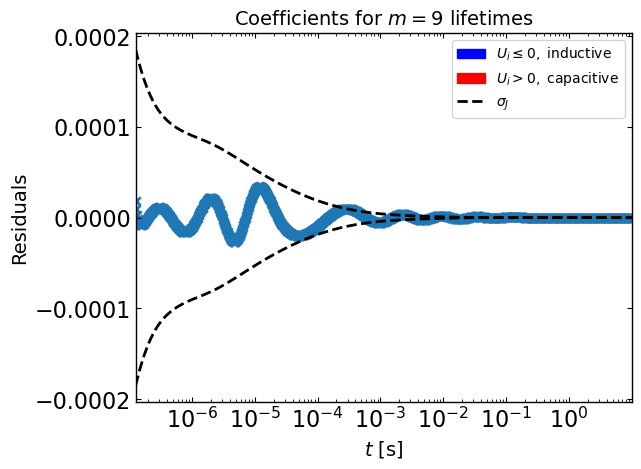

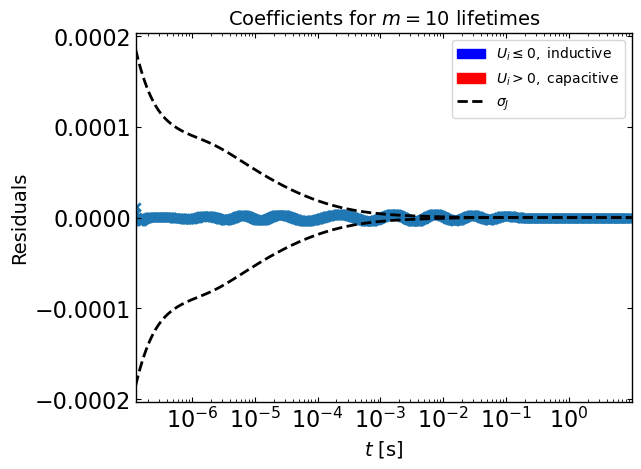

In [173]:
# Print the residuals of each fit 
for fit in fits_unscaled:
    # plt.vlines(fit.tau, ymin=0, ymax=fit.U, colors=colour_map, linestyles='-.')
    plt.scatter(time, (current - data['Jext'].iloc[-1] - fit.DRT_curve), marker='x')
    plt.plot(time, current_error, label='$\\sigma_J$', color='black', linestyle='--')
    plt.plot(time, -current_error, label='$\\sigma_J$', color='black', linestyle='--')
    plt.xlim(xlim)
    plt.xlabel("$t$ [s]")
    plt.ylabel(f"Residuals")
    plt.xscale("log")
    plt.yscale("linear")
    plt.title(f"Coefficients for $m=${fit.m} lifetimes")
    plt.legend(handles =[blue_patch, red_patch, black_line], prop={'size': 10})
    plt.show()

## Linear Fit

In [184]:
# Define linear fit
def linear_fit_DRT(t, J, tau):
    # Make sure array-like objects are numpy arrays
    t = np.array(t)
    J = np.array(J)
    tau = np.array(tau)

    # Create initial guess for U 
    M = len(tau)
    U0 = np.zeros(M)

    # Create an initial array-like guess of variables
    x0 = np.concatenate((U0, np.array([0])))

    # Assume an array of dimension M + M + 1, where the first M values 
    # correspond to U values, the second group of M values to the tau values 
    # and the final value to the offset
    error = lambda x : ((x[:-1] @ np.exp(-np.outer(1/tau, t))) + x[-1]) - J

    fit = so.least_squares(error, x0=x0)

    # Assume params is of dimension 2 x m, where m is the number of tau/U_values
    return fit